In [112]:
words = []
with open('names.txt', 'r') as f:
    words = f.read().split()
    
print(words)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn', 'abigail', 'emily', 'elizabeth', 'mila', 'ella', 'avery', 'sofia', 'camila', 'aria', 'scarlett', 'victoria', 'madison', 'luna', 'grace', 'chloe', 'penelope', 'layla', 'riley', 'zoey', 'nora', 'lily', 'eleanor', 'hannah', 'lillian', 'addison', 'aubrey', 'ellie', 'stella', 'natalie', 'zoe', 'leah', 'hazel', 'violet', 'aurora', 'savannah', 'audrey', 'brooklyn', 'bella', 'claire', 'skylar', 'lucy', 'paisley', 'everly', 'anna', 'caroline', 'nova', 'genesis', 'emilia', 'kennedy', 'samantha', 'maya', 'willow', 'kinsley', 'naomi', 'aaliyah', 'elena', 'sarah', 'ariana', 'allison', 'gabriella', 'alice', 'madelyn', 'cora', 'ruby', 'eva', 'serenity', 'autumn', 'adeline', 'hailey', 'gianna', 'valentina', 'isla', 'eliana', 'quinn', 'nevaeh', 'ivy', 'sadie', 'piper', 'lydia', 'alexa', 'josephine', 'emery', 'julia', 'delilah', 'arianna', 'vivian', 'kaylee', 'sophie', 'brielle', 'madeline', 'peyton', 'ryle

In [113]:

b = {}
for w in words:
    char = ['<S>'] + list(w) + ['<E>']
    for f, s in zip(char, char[1:]):
        bigram = (f,s)
        b[bigram] = b.get(bigram, 0) + 1        


In [114]:
sorted(b.items(), key= lambda item: item[1], reverse=True)


[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [115]:
import torch

In [116]:
N = torch.zeros((27,27), dtype=torch.int32)

In [117]:
charac = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(charac)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(charac, stoi, itos, len(charac))


['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'] {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0} {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'} 26


In [118]:
for w in words:
    char = ['.'] + list(w) + ['.']
    for f, s in zip(char, char[1:]):
        i1 = stoi[f]
        i2 = stoi[s]
        N[i1,i2] +=1

In [119]:
print(N)

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

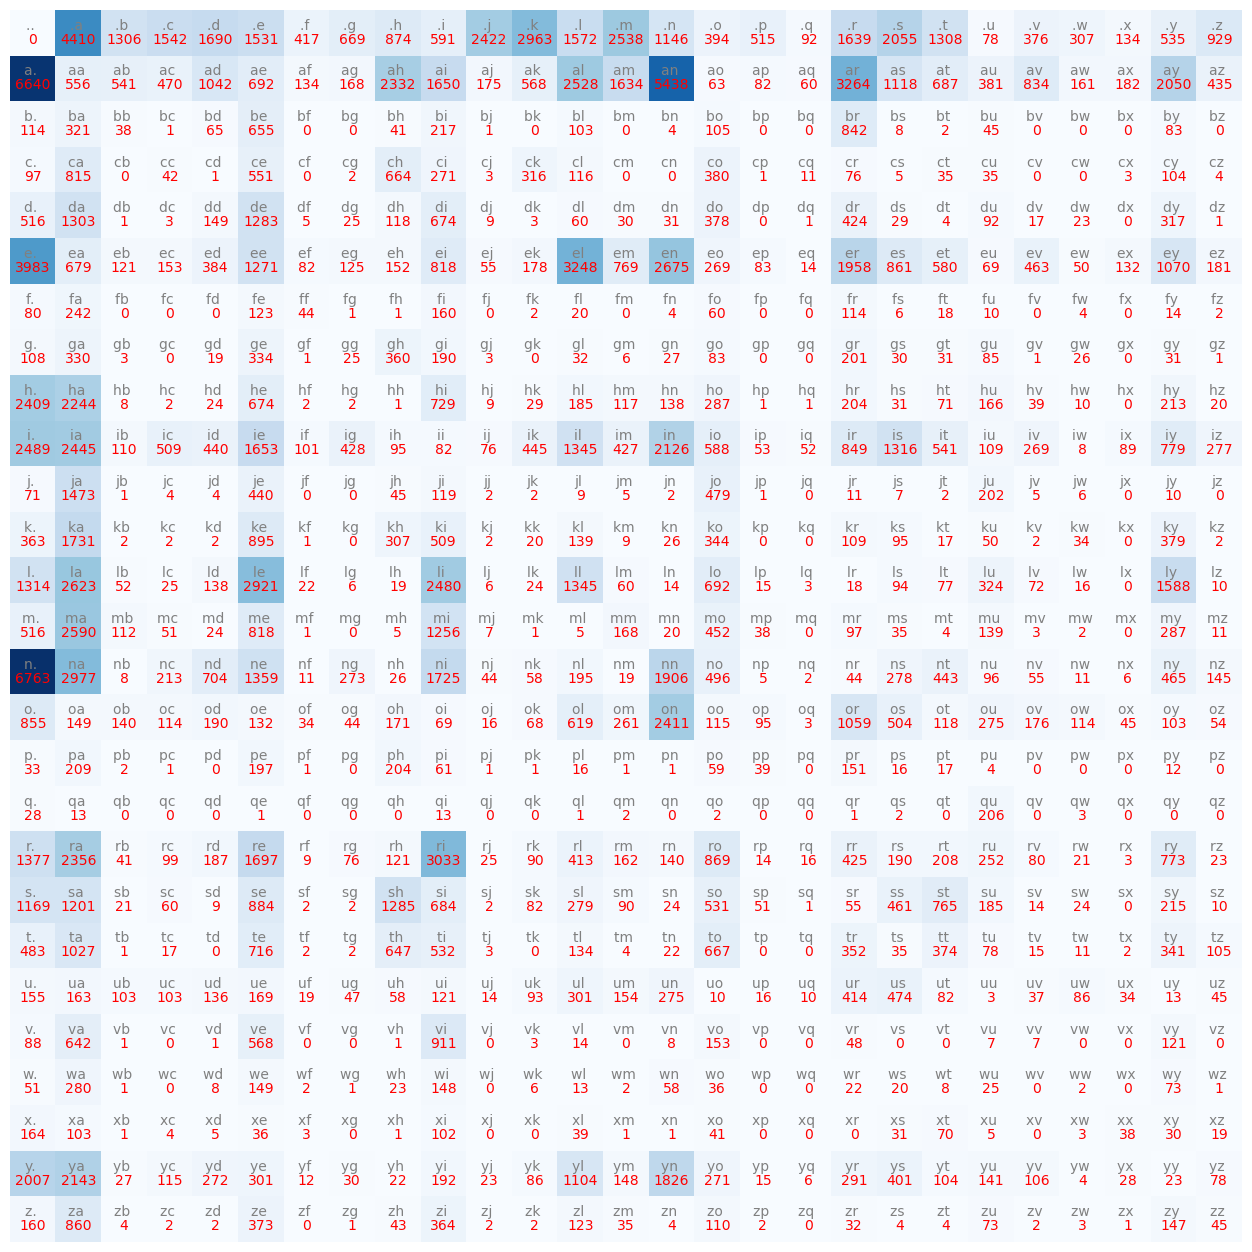

In [120]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr + ' ' , ha='center', va='bottom', color='gray')
        plt.text(j, i, str(N[i,j].item()), ha='center', va='top', color='red')
plt.axis('off')
plt.show()

In [121]:
p = N[0].float()

p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [122]:
P = N.float()
P = P / P.sum(1, keepdim=True)
P
P.shape

torch.Size([27, 27])

In [123]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        x = P[ix]
        ix = torch.multinomial(x, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [124]:
# now lets fnd the loss fn from trainign set
log_likelihood = 0.0
n = 0

for w in words[:3]:
    char = ['.'] + list(w) + ['.']
    for f, s in zip(char, char[1:]):
        i1 = stoi[f]
        i2 = stoi[s]
        prob = P[i1,i2]
        prob = torch.log(prob)
        log_likelihood += prob.item()
        n +=1
        print(f'{f} {s} {prob:.4f}')

print(f'Loss: {-log_likelihood/n}')                    # we just want to minimize the negative log likelihood, so we put a negative sign in front of it.

. e -3.0408
e m -3.2793
m m -3.6772
m a -0.9418
a . -1.6299
. o -4.3982
o l -2.5508
l i -1.7278
i v -4.1867
v i -1.0383
i a -1.9796
a . -1.6299
. a -1.9829
a v -3.7045
v a -1.3882
a . -1.6299
Loss: 2.4241022877395153


In [146]:
# making the dataset
xc = []
yc = []

for w in words:
    char = ['.'] + list(w) + ['.']
    for f, s in zip(char, char[1:]):
        i1 = stoi[f]
        i2 = stoi[s]
        xc.append(i1)
        yc.append(i2)

xc = torch.tensor(xc)
yc = torch.tensor(yc)
num = xc.nelement()
print(num)



228146


In [141]:
xc , yc


(tensor([ 0,  5, 13,  ..., 25, 26, 24]),
 tensor([ 5, 13, 13,  ..., 26, 24,  0]))

In [148]:
import torch.nn.functional as F
xenc = F.one_hot(xc, num_classes=27).float()
xenc.shape


torch.Size([228146, 27])

In [149]:
g = torch.Generator().manual_seed(2147483647)
w = torch.randn((27,27), generator=g , requires_grad=True)


In [130]:
# (5 , 27) @ (27, 27) -> (5, 27)

In [154]:
# now we have exact data for forward pass and backprop

losses = []
for i in range(500):
    logits = xenc @ w
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    probs.shape

    loss = -probs[torch.arange(num), yc].log().mean()
    loss

    #backward pass
    w.grad = None
    loss.backward()
    losses.append(loss.item())

    #update weights 

    w.data += -20 * w.grad
    print(f'Iter {i} Loss: {loss.item()}')


Iter 0 Loss: 3.376755952835083
Iter 1 Loss: 3.277592182159424
Iter 2 Loss: 3.1969809532165527
Iter 3 Loss: 3.1306240558624268
Iter 4 Loss: 3.0749871730804443
Iter 5 Loss: 3.0275042057037354
Iter 6 Loss: 2.986431121826172
Iter 7 Loss: 2.950562000274658
Iter 8 Loss: 2.9190123081207275
Iter 9 Loss: 2.8910927772521973
Iter 10 Loss: 2.866241931915283
Iter 11 Loss: 2.843996524810791
Iter 12 Loss: 2.82397198677063
Iter 13 Loss: 2.805846929550171
Iter 14 Loss: 2.789355516433716
Iter 15 Loss: 2.774275064468384
Iter 16 Loss: 2.7604215145111084
Iter 17 Loss: 2.74764084815979
Iter 18 Loss: 2.7358036041259766
Iter 19 Loss: 2.724801540374756
Iter 20 Loss: 2.714543581008911
Iter 21 Loss: 2.7049524784088135
Iter 22 Loss: 2.6959621906280518
Iter 23 Loss: 2.687516212463379
Iter 24 Loss: 2.679565906524658
Iter 25 Loss: 2.672069549560547
Iter 26 Loss: 2.664989709854126
Iter 27 Loss: 2.658294439315796
Iter 28 Loss: 2.6519548892974854
Iter 29 Loss: 2.6459453105926514
Iter 30 Loss: 2.640241861343384
Iter 31 

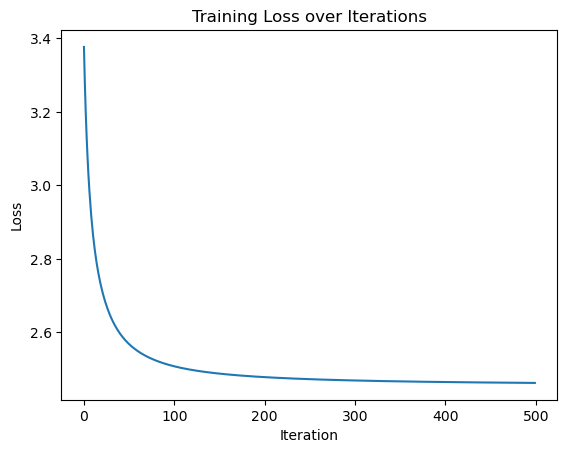

In [155]:
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss over Iterations')
plt.show()